# Clinical Trial Simulation: Drug Effect in Streaming EHR Data

**Scenario:** Patients arrive at a hospital one at a time. Each patient may
receive a new drug (treatment=1) or standard care (treatment=0). We want to
estimate the drug's average effect in real time using observational data, and
detect if the effect changes over time (e.g. due to patient population drift).

**Challenges modelled:**
- Confounding: sicker patients are more likely to receive the drug
- Heterogeneous effects: drug is more effective for high-risk patients
- Concept drift: patient population changes halfway through (e.g. new ward)

**Methods:** OnlineAIPW (doubly robust), OnlineRLearner, ConceptDriftMonitor

In [1]:
import matplotlib
import matplotlib.pyplot as plt

from river.linear_model import LinearRegression

from onlinecml.datasets import HeterogeneousCausalStream, DriftingCausalStream
from onlinecml.reweighting import OnlineAIPW
from onlinecml.metalearners import OnlineRLearner
from onlinecml.diagnostics import ConceptDriftMonitor, OverlapChecker
from onlinecml.evaluation import progressive_causal_score
from onlinecml.evaluation.metrics import ATEError, PEHE, CIcoverage

## 1. Stable patient population

Final ATE error  : 0.0014
Final PEHE       : 0.5260
CI coverage      : 99.7%


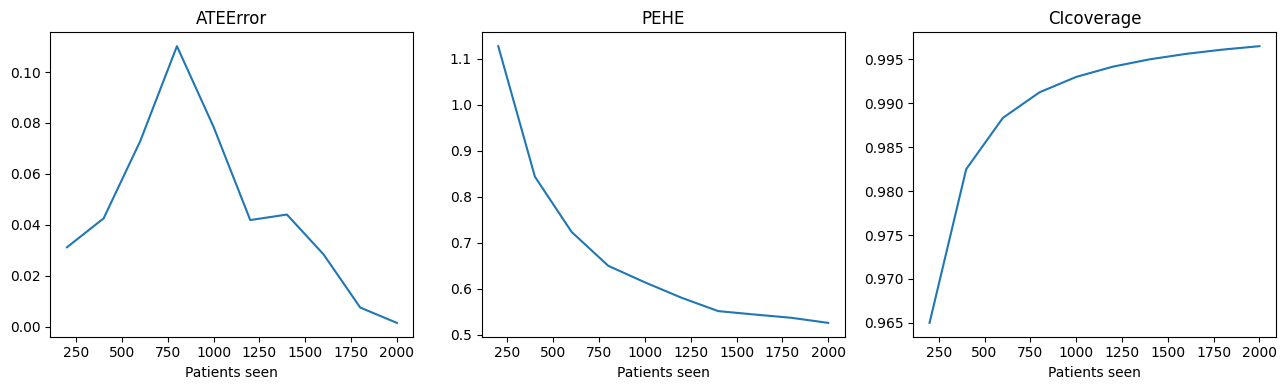

In [2]:
results = progressive_causal_score(
    stream  = HeterogeneousCausalStream(
        n=2000, true_ate=1.5, heterogeneity="nonlinear",
        confounding_strength=0.8, seed=0
    ),
    model   = OnlineAIPW(),
    metrics = [ATEError(), PEHE(), CIcoverage()],
    step    = 200,
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric in zip(axes, ["ATEError", "PEHE", "CIcoverage"]):
    ax.plot(results["steps"], results[metric])
    ax.set_title(metric)
    ax.set_xlabel("Patients seen")
plt.tight_layout()
plt.savefig("/tmp/clinical_stable.png", dpi=100)
print(f"Final ATE error  : {results['ATEError'][-1]:.4f}")
print(f"Final PEHE       : {results['PEHE'][-1]:.4f}")
print(f"CI coverage      : {results['CIcoverage'][-1]:.1%}")

## 2. Drifting patient population

Drifts detected: 1
Overlap adequate: True


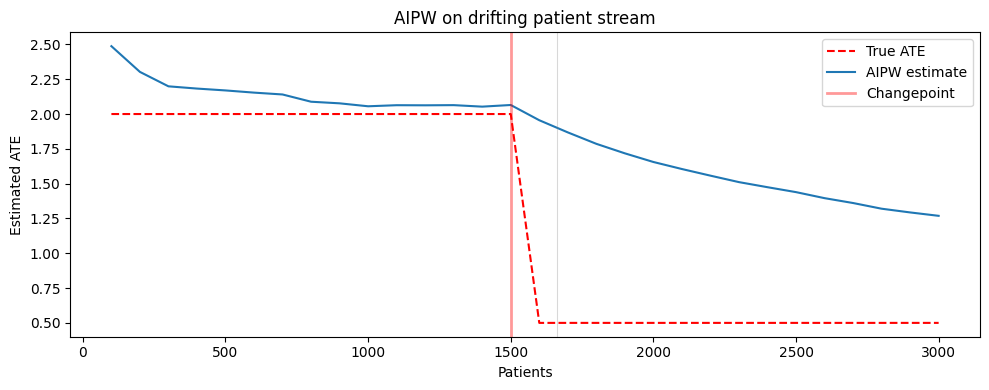

In [3]:
aipw = OnlineAIPW()
monitor = ConceptDriftMonitor(delta=0.002)
overlap = OverlapChecker()

ates, steps_log = [], []
drift_steps = []

for i, (x, w, y, tau) in enumerate(
    DriftingCausalStream(n=3000, true_ate=2.0, shifted_ate=0.5,
                         changepoint=1500, seed=7)
):
    ps = aipw.ps_model.predict_one(x)
    overlap.update(ps, treatment=w)

    # Compute pseudo-outcome for drift monitor
    ps_c = max(0.01, min(0.99, ps))
    psi  = (w * y / ps_c) - ((1 - w) * y / (1 - ps_c))
    monitor.update(psi)
    if monitor.drift_detected:
        drift_steps.append(i)

    aipw.learn_one(x, w, y)

    if (i + 1) % 100 == 0:
        steps_log.append(i + 1)
        ates.append(aipw.predict_ate())

true_curve = [2.0 if s <= 1500 else 0.5 for s in steps_log]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps_log, true_curve, "r--", label="True ATE")
ax.plot(steps_log, ates, label="AIPW estimate")
for d in drift_steps:
    ax.axvline(d, color="gray", alpha=0.3, linewidth=0.8)
ax.axvline(1500, color="red", alpha=0.4, linewidth=2, label="Changepoint")
ax.set_xlabel("Patients")
ax.set_ylabel("Estimated ATE")
ax.set_title("AIPW on drifting patient stream")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/clinical_drift.png", dpi=100)
print(f"Drifts detected: {monitor.n_drifts}")
print(f"Overlap adequate: {overlap.is_overlap_adequate()}")

## 3. CATE by subgroup

In [4]:
rl = OnlineRLearner(cate_model=LinearRegression())

for x, w, y, _ in HeterogeneousCausalStream(
    n=2000, true_ate=1.5, heterogeneity="nonlinear",
    confounding_strength=0.8, seed=0
):
    rl.learn_one(x, w, y)

# Predict for low-risk (x0=-2) vs high-risk (x0=+2) patients
import math
print("CATE by patient risk (x0 = risk score proxy):")
for x0 in [-2.0, -1.0, 0.0, 1.0, 2.0]:
    x_test = {"x0": x0, "x1": 0.0, "x2": 0.0, "x3": 0.0, "x4": 0.0}
    cate = rl.predict_one(x_test)
    # True CATE (nonlinear DGP): true_ate + x0 + sin(x1)*0.5
    true_cate = 1.5 + x0 + math.sin(0.0) * 0.5
    print(f"  x0={x0:+.1f}  CATE_hat={cate:+.3f}  true={true_cate:+.3f}")

CATE by patient risk (x0 = risk score proxy):
  x0=-2.0  CATE_hat=-0.724  true=-0.500
  x0=-1.0  CATE_hat=+0.344  true=+0.500
  x0=+0.0  CATE_hat=+1.412  true=+1.500
  x0=+1.0  CATE_hat=+2.480  true=+2.500
  x0=+2.0  CATE_hat=+3.549  true=+3.500
